In [130]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [131]:
df_cancer = pd.read_csv('../../data/Breast cancer.csv')
df_cancer.head()

,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,nucleo_descoberto,cromatina_branda,nucleolos_normais,mitose,classe
0,5,1,1,1,2,1,3,1,1,benigno
1,5,4,4,5,7,10,3,2,1,benigno
2,3,1,1,1,2,2,3,1,1,benigno
3,6,8,8,1,3,4,3,7,1,benigno
4,4,1,1,3,2,1,3,1,1,benigno


### Validar valores missing

In [132]:
df_cancer.isnull().sum()

espessura                   0
uniformidade_tamanho        0
uniformidade_forma          0
aderencia_marginal          0
tamanho_celula_epitelial    0
nucleo_descoberto           0
cromatina_branda            0
nucleolos_normais           0
mitose                      0
classe                      0
dtype: int64

In [133]:
## Nenhum valor nulo identificado, podemos seguir com a análise exploratória dos dados.

### Avaliar correlações entre as variáveis

In [134]:
# Corrigir "?" nas colunas e calcular correlação só entre variáveis numéricas
cols_num = df_cancer.columns.drop('classe')
df_cancer[cols_num] = df_cancer[cols_num].apply(pd.to_numeric, errors='coerce')

df_cancer[cols_num].corr()


,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,nucleo_descoberto,cromatina_branda,nucleolos_normais,mitose
espessura,1.000000,0.644913,0.654589,0.486356,0.521816,0.593091,0.558428,0.535835,0.350034
uniformidade_tamanho,0.644913,1.000000,0.906882,0.705582,0.751799,0.691709,0.755721,0.722865,0.458693
uniformidade_forma,0.654589,0.906882,1.000000,0.683079,0.719668,0.713878,0.735948,0.719446,0.438911
aderencia_marginal,0.486356,0.705582,0.683079,1.000000,0.599599,0.670648,0.666715,0.603352,0.417633
tamanho_celula_epitelial,0.521816,0.751799,0.719668,0.599599,1.000000,0.585716,0.616102,0.628881,0.479101
nucleo_descoberto,0.593091,0.691709,0.713878,0.670648,0.585716,1.000000,0.680615,0.584280,0.339210
cromatina_branda,0.558428,0.755721,0.735948,0.666715,0.616102,0.680615,1.000000,0.665878,0.344169
nucleolos_normais,0.535835,0.722865,0.719446,0.603352,0.628881,0.584280,0.665878,1.000000,0.428336
mitose,0.350034,0.458693,0.438911,0.417633,0.479101,0.339210,0.344169,0.428336,1.000000


### Avaliar a distrubuição das classes

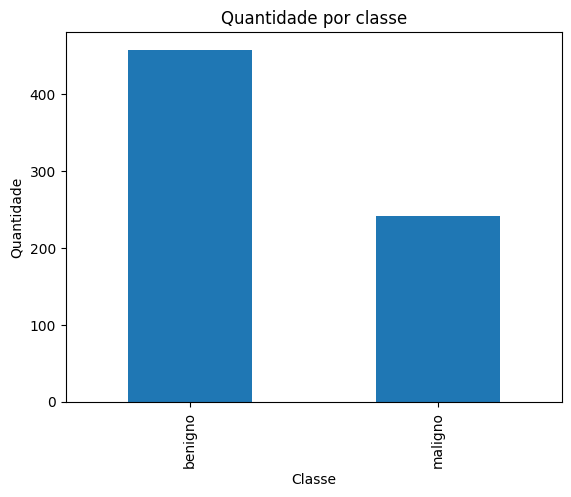

In [135]:
df_cancer['classe'].value_counts().plot(kind='bar')
plt.title('Quantidade por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

In [136]:
# Escolha aqui as variáveis que quer visualizar
variaveis = ["espessura", "uniformidade_tamanho", "uniformidade_forma"]
coluna_classe = "classe"  # use None se não quiser colorir por classe
df_plot = df_cancer  # pode trocar para df_cancer_smote

# Validação simples
faltando = [v for v in variaveis if v not in df_plot.columns]
if faltando:
    raise ValueError(f"Colunas não encontradas no DataFrame: {faltando}")

if len(variaveis) == 1:
    fig = px.histogram(
        df_plot,
        x=variaveis[0],
        color=coluna_classe if coluna_classe in df_plot.columns else None,
        barmode="overlay",
        title=f"Distribuição de {variaveis[0]}"
    )
elif len(variaveis) == 2:
    fig = px.scatter(
        df_plot,
        x=variaveis[0],
        y=variaveis[1],
        color=coluna_classe if coluna_classe in df_plot.columns else None,
        title=f"{variaveis[0]} vs {variaveis[1]}"
    )
elif len(variaveis) == 3:
    fig = px.scatter_3d(
        df_plot,
        x=variaveis[0],
        y=variaveis[1],
        z=variaveis[2],
        color=coluna_classe if coluna_classe in df_plot.columns else None,
        title=f"{variaveis[0]} vs {variaveis[1]} vs {variaveis[2]}"
    )
else:
    fig = px.scatter_matrix(
        df_plot,
        dimensions=variaveis,
        color=coluna_classe if coluna_classe in df_plot.columns else None,
        title="Matriz de dispersão das variáveis selecionadas"
    )

fig.update_layout(template="plotly_white")
fig.show()

### Validando a escala do modelo

In [137]:
df_cancer.describe()

,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,nucleo_descoberto,cromatina_branda,nucleolos_normais,mitose
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


## Chamando o modelo

In [138]:
# Preparar dados
X = df_cancer[cols_num].copy()
y = df_cancer["classe"].copy()
X = X.fillna(X.median(numeric_only=True))

# Dividir antes de qualquer balanceamento (evita vazamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar para KNN (fit no treino, transform no treino e teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = KNeighborsClassifier(n_neighbors=100)

### balanceamento das classes nos dados de treino

In [ ]:
# Aplicar SMOTE apenas no treino (já escalado)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Apenas para visualização do balanceamento do treino
print("Treino antes do SMOTE:")
print(y_train.value_counts())
print("\nTreino depois do SMOTE:")
print(y_train_res.value_counts())

Antes do SMOTE:
classe
benigno    458
maligno    241
Name: count, dtype: int64

Depois do SMOTE:
classe
benigno    458
maligno    458
Name: count, dtype: int64


In [139]:
if "X_train_res" not in globals() or "y_train_res" not in globals():
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

model_knn.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",100
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Avaliação do modelo

Acurácia=0.9500 | Precisão=0.9499 | Recall=0.9500 | F1=0.9499


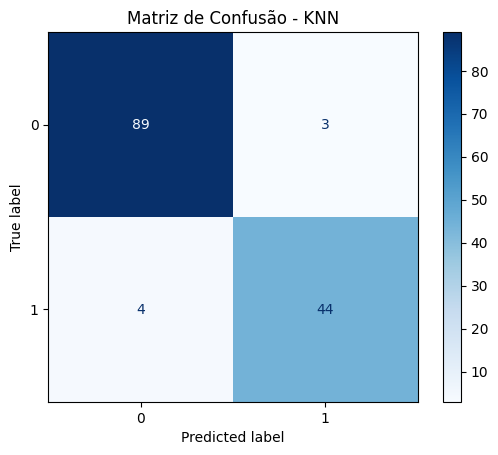

In [140]:
y_pred = model_knn.predict(X_test_scaled)

acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Acurácia={acuracia:.4f} | Precisão={precisao:.4f} | Recall={recall:.4f} | F1={f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Matriz de Confusão - KNN")
plt.show()